In [52]:
import pickle
import xml.etree.ElementTree as ET
from lxml import etree
import redis
import sqlite3
import duckdb
import psycopg2
from pymongo import MongoClient

import random
from tqdm import tqdm
from datetime import datetime
from faker import Faker

import pandas as pd
import matplotlib.pyplot as plt


first_run= False
use_xml_backup = True

if first_run and use_xml_backup:
    print("⚠️\tYou must not set first_run and use_xml_backup to 'True' at the same time.\n\tThe XML backup will be created at the first run.\n")

verbose=True

pg_host="localhost"
pg_port=5432
pg_database="david"
pg_user="david"
pg_password="david"

stats={'db':[],
            }
stats['db'].append('xml')
stats['db'].append('lxml')
stats['db'].append('redis')
stats['db'].append('sqlite3')
stats['db'].append('duckdb')
stats['db'].append('postgres')
stats['db'].append('mongodb')
stats['db'].append('mongodb (idx)')


experimental_runs=[
    1,
    10,
    100,
    1000,
    10000,
    100000,
    200000,
    500000,
]

for experiment in experimental_runs:
    stats[experiment]=[]

init_times={'db':[],
            'duration':[]
            }
init_times['db'].append('xml')
init_times['db'].append('lxml')
init_times['db'].append('redis')
init_times['db'].append('sqlite3')
init_times['db'].append('duckdb')
init_times['db'].append('postgres')
init_times['db'].append('mongodb')
init_times['db'].append('mongodb (idx)')


# generate fake data (only relevant for RDBMS)
fake = Faker()

fake_k=100000
fake_numbers = random.sample(range(100_000_000, 1_000_000_000), k=fake_k)
fake_ppns=["PPx"+str(x) for x in fake_numbers]
fake_titles=[fake.sentence() for _ in range(fake_k)]


startTime = datetime.now()
xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

tree = ET.parse(xmlPath)
root = tree.getroot()


# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                #print(f"\thref: {str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])}")

endTime = datetime.now()
duration = endTime - startTime

init_xml=duration.total_seconds()
init_times['duration'].append(init_xml)

print(f"Duration:\t{str(duration)}")
print("\nStarted at:\t%s\nEnded at:\t%s" % (startTime, endTime))
print(f"Max index:\t{maxIndex}")

Duration:	0:00:00.006687

Started at:	2026-05-13 23:48:32.644553
Ended at:	2026-05-13 23:48:32.651240
Max index:	341


## XML

__ATTENTION:__ Do not move this block otherwise the XML backup mechanism will not work. Only add other DBs after the LXML block.

In [53]:
def getPageFromXML(index):
    xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

    tree = ET.parse(xmlPath)
    root = tree.getroot()
    for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
        for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
            currentUse = child.attrib["USE"]

            firstFileNode = True
            if currentUse== "PRESENTATION":
                # which contains file nodes...
                for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                    # embedding FLocat node pointing to the URLs of interest
                    id = fileNode.attrib["ID"]
                    currentIndex=int(id.split("_")[1])
                    if currentIndex==index:
                        # returns the href to the presentation index
                        return str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])

In [54]:
if not use_xml_backup or first_run:
    for experiment in experimental_runs:
        startTime = datetime.now()
        for i in tqdm(range(experiment)):
            selectedPage=random.randint(1, maxIndex)
            returnedHref=getPageFromXML(selectedPage)
        endTime = datetime.now()

        duration = endTime - startTime
        stats[experiment].append(duration.total_seconds())

        print("%i runs\nStarted at:\t%s\nEnded at:\t%s" % (experiment,startTime, endTime))
        print(f"Duration:\t{str(duration)}\n")
else:
    print("Restoring from XML backup.")
    stats=pickle.load(open("../data/stats_after_xml.pickle", "rb"))
display(stats)

Restoring from XML backup.


{'db': ['xml',
  'lxml',
  'redis',
  'sqlite3',
  'duckdb',
  'postgres',
  'mongodb',
  'mongodb (idx)'],
 1: [0.007537,
  0.022818,
  0.006384,
  0.001679,
  0.011523,
  0.002011,
  0.002225,
  0.004508],
 10: [0.050186,
  0.101891,
  0.005463,
  0.002547,
  0.006243,
  0.001712,
  0.004254,
  0.007237],
 100: [0.536439,
  0.94766,
  0.028751,
  0.003127,
  0.021371,
  0.009936,
  0.03141,
  0.036092],
 1000: [5.499903,
  12.092274,
  0.067401,
  0.017621,
  0.189986,
  0.063649,
  0.377124,
  0.25412],
 10000: [53.976103,
  85.336277,
  0.565569,
  0.129181,
  2.068105,
  0.496856,
  4.289106,
  2.141709],
 100000: [596.917525,
  790.884542,
  3.109839,
  1.254123,
  20.045159,
  4.611127,
  27.441313,
  20.46168],
 200000: [1393.225673,
  1410.675546,
  5.60693,
  2.395146,
  40.014462,
  9.947668,
  50.497134,
  39.94612],
 500000: [4867.803601,
  3343.513859,
  13.760545,
  5.979178,
  95.544111,
  23.791944,
  137.542997,
  99.037198]}

In [55]:
# as the XML processing takes quite a while we will make a backup to continue from this cell on the first run.
if first_run:
    pickle.dump(stats, open("../data/stats_after_xml.pickle", "wb"))
    print("Saved XML backup.")

## LXML

__ATTENTION:__ Do not move this block otherwise the XML backup mechanism will not work. Only add other DBs after the LXML block.

In [56]:
def getPageFromLXML(index):
    xmlPath="../data/xml/sample/__metsmods/PPN745182844.xml"

    tree = etree.parse(xmlPath)
    root = tree.getroot()
    for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
        for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
            currentUse = child.attrib["USE"]

            firstFileNode = True
            if currentUse== "PRESENTATION":
                # which contains file nodes...
                for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                    # embedding FLocat node pointing to the URLs of interest
                    id = fileNode.attrib["ID"]
                    currentIndex=int(id.split("_")[1])
                    if currentIndex==index:
                        # returns the href to the presentation index
                        return str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])

if not use_xml_backup or first_run:
    for experiment in experimental_runs:
        startTime = datetime.now()
        for i in tqdm(range(experiment)):
            selectedPage=random.randint(1, maxIndex)
            returnedHref=getPageFromLXML(selectedPage)
        endTime = datetime.now()

        duration = endTime - startTime
        stats[experiment].append(duration.total_seconds())

        print("%i runs\nStarted at:\t%s\nEnded at:\t%s" % (experiment,startTime, endTime))
        print(f"Duration:\t{str(duration)}\n")
else:
    print("Restoring from XML backup.")
    stats=pickle.load(open("../data/stats_after_lxml.pickle", "rb"))
# dummy init time
init_times['duration'].append(init_xml)
display(stats)

Restoring from XML backup.


{'db': ['xml',
  'lxml',
  'redis',
  'sqlite3',
  'duckdb',
  'postgres',
  'mongodb',
  'mongodb (idx)'],
 1: [0.007537, 0.022818],
 10: [0.050186, 0.101891],
 100: [0.536439, 0.94766],
 1000: [5.499903, 12.092274],
 10000: [53.976103, 85.336277],
 100000: [596.917525, 790.884542],
 200000: [1393.225673, 1410.675546],
 500000: [4867.803601, 3343.513859]}

In [57]:
# as the XML processing takes quite a while we will make a backup to continue from this cell on the first run.
if first_run:
    pickle.dump(stats, open("../data/stats_after_lxml.pickle", "wb"))
    print("Saved XML backup (for LXML run).")

## Redis


In [58]:
startTime = datetime.now()
r = redis.Redis(host='localhost', port=6379, decode_responses=True)
r.flushall()

tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                r.set(currentIndex,str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]))
endTime = datetime.now()
duration = endTime - startTime
init_redis=duration.total_seconds()
init_times['duration'].append(init_redis)

In [59]:
for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=r.get(selectedPage)

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

r.close()
display(stats)

100%|██████████| 1/1 [00:00<00:00, 712.71it/s]


1 runs
Started at:	2026-05-13 23:48:32.780426
Ended at:	2026-05-13 23:48:32.782906

Duration:	0:00:00.002480



100%|██████████| 10/10 [00:00<00:00, 13720.33it/s]


10 runs
Started at:	2026-05-13 23:48:32.782930
Ended at:	2026-05-13 23:48:32.784242

Duration:	0:00:00.001312



100%|██████████| 100/100 [00:00<00:00, 21074.79it/s]


...

100%|██████████| 200000/200000 [00:05<00:00, 34060.41it/s]


200000 runs
Started at:	2026-05-13 23:48:36.071544
Ended at:	2026-05-13 23:48:41.944139

Duration:	0:00:05.872595



100%|██████████| 500000/500000 [00:14<00:00, 34199.09it/s]

500000 runs
Started at:	2026-05-13 23:48:41.944159
Ended at:	2026-05-13 23:48:56.565114

Duration:	0:00:14.620955



{'db': ['xml',
  'lxml',
  'redis',
  'sqlite3',
  'duckdb',
  'postgres',
  'mongodb',
  'mongodb (idx)'],
 1: [0.007537, 0.022818, 0.00248],
 10: [0.050186, 0.101891, 0.001312],
 100: [0.536439, 0.94766, 0.005304],
 1000: [5.499903, 12.092274, 0.043365],
 10000: [53.976103, 85.336277, 0.301781],
 100000: [596.917525, 790.884542, 2.936751],
 200000: [1393.225673, 1410.675546, 5.872595],
 500000: [4867.803601, 3343.513859, 14.620955]}

## SQLite

In [60]:
startTime = datetime.now()

tree = ET.parse(xmlPath)
root = tree.getroot()

con = sqlite3.connect("../data/sqlite/htw.db")
cur = con.cursor()

cur.execute("DROP TABLE IF EXISTS media;")
cur.execute("CREATE TABLE media (ppn PRIMARY KEY, dummy_data NOT NULL);")

cur.execute("DROP TABLE IF EXISTS documents;")
cur.execute("CREATE TABLE documents (ppn NOT NULL, page NOT NULL, href NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
cur.execute("INSERT INTO media VALUES (?, ?);", (sample_ppn,dummy_text))

# add fake documents:
for i in range(fake_k):
    cur.execute("INSERT INTO media VALUES (?, ?);", (fake_ppns[i],fake_titles[i]))

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                cur.execute("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

cur.close()
con.commit()
con.close()

endTime = datetime.now()
duration = endTime - startTime
init_sqlite=duration.total_seconds()

init_times['duration'].append(init_sqlite)

In [61]:
con = sqlite3.connect("../data/sqlite/htw.db")
cur = con.cursor()

for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page="+str(selectedPage)+";"
        returnedHref=cur.execute(sql_cmd).fetchone()

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

cur.close()
con.close()

display(stats)

1


100%|██████████| 1/1 [00:00<00:00, 2498.10it/s]


1 runs
Started at:	2026-05-13 23:48:56.748492
Ended at:	2026-05-13 23:48:56.749926

Duration:	0:00:00.001434

10


100%|██████████| 10/10 [00:00<00:00, 13720.33it/s]


10 runs
Started at:	2026-05-13 23:48:56.749944
Ended at:	2026-05-13 23:48:56.751541

Duration:	0:00:00.001597

100


...

100%|██████████| 200000/200000 [00:02<00:00, 89394.27it/s]


200000 runs
Started at:	2026-05-13 23:48:58.005247
Ended at:	2026-05-13 23:49:00.243299

Duration:	0:00:02.238052

500000


100%|██████████| 500000/500000 [00:05<00:00, 89230.37it/s]

500000 runs
Started at:	2026-05-13 23:49:00.243324
Ended at:	2026-05-13 23:49:05.847469

Duration:	0:00:05.604145



{'db': ['xml',
  'lxml',
  'redis',
  'sqlite3',
  'duckdb',
  'postgres',
  'mongodb',
  'mongodb (idx)'],
 1: [0.007537, 0.022818, 0.00248, 0.001434],
 10: [0.050186, 0.101891, 0.001312, 0.001597],
 100: [0.536439, 0.94766, 0.005304, 0.003154],
 1000: [5.499903, 12.092274, 0.043365, 0.013804],
 10000: [53.976103, 85.336277, 0.301781, 0.114009],
 100000: [596.917525, 790.884542, 2.936751, 1.122638],
 200000: [1393.225673, 1410.675546, 5.872595, 2.238052],
 500000: [4867.803601, 3343.513859, 14.620955, 5.604145]}

## DuckDB

In [62]:
startTime = datetime.now()

tree = ET.parse(xmlPath)
root = tree.getroot()

duckdb.close()
duckdb.sql("DROP TABLE IF EXISTS media CASCADE;")
duckdb.sql("CREATE TABLE media (ppn VARCHAR(12) PRIMARY KEY, dummy_data VARCHAR (50) NOT NULL);")

duckdb.sql("DROP TABLE IF EXISTS documents CASCADE;")
duckdb.sql("CREATE TABLE documents (ppn VARCHAR(12) NOT NULL, page INT NOT NULL, href VARCHAR(200) NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
duckdb.sql("INSERT INTO media VALUES (?, ?)", params=[sample_ppn,dummy_text])

for i in range(fake_k):
    duckdb.sql("INSERT INTO media VALUES (?, ?);", params=[fake_ppns[i],fake_titles[i]])

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                duckdb.sql("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

endTime = datetime.now()
duration = endTime - startTime
init_duckdb=duration.total_seconds()

init_times['duration'].append(init_duckdb)


In [63]:
for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page=?;"

        returnedHref=duckdb.sql(sql_cmd,params=[selectedPage]).fetchone()



    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())
    print("apend")

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

duckdb.close() # closes and deletes the in-memory db

display(stats)

1


100%|██████████| 1/1 [00:00<00:00, 168.19it/s]


apend
1 runs
Started at:	2026-05-13 23:49:15.765102
Ended at:	2026-05-13 23:49:15.772077

Duration:	0:00:00.006975

10


100%|██████████| 10/10 [00:00<00:00, 2854.63it/s]


apend
10 runs
Started at:	2026-05-13 23:49:15.772102
Ended at:	2026-05-13 23:49:15.776464

Duration:	0:00:00.004362

100


...

100%|██████████| 200000/200000 [00:35<00:00, 5657.57it/s]


apend
200000 runs
Started at:	2026-05-13 23:49:35.375687
Ended at:	2026-05-13 23:50:10.727811

Duration:	0:00:35.352124

500000


100%|██████████| 500000/500000 [01:37<00:00, 5138.93it/s]

apend
500000 runs
Started at:	2026-05-13 23:50:10.727839
Ended at:	2026-05-13 23:51:48.025177

Duration:	0:01:37.297338



{'db': ['xml',
  'lxml',
  'redis',
  'sqlite3',
  'duckdb',
  'postgres',
  'mongodb',
  'mongodb (idx)'],
 1: [0.007537, 0.022818, 0.00248, 0.001434, 0.006975],
 10: [0.050186, 0.101891, 0.001312, 0.001597, 0.004362],
 100: [0.536439, 0.94766, 0.005304, 0.003154, 0.021094],
 1000: [5.499903, 12.092274, 0.043365, 0.013804, 0.179315],
 10000: [53.976103, 85.336277, 0.301781, 0.114009, 1.761975],
 100000: [596.917525, 790.884542, 2.936751, 1.122638, 17.636715],
 200000: [1393.225673, 1410.675546, 5.872595, 2.238052, 35.352124],
 500000: [4867.803601, 3343.513859, 14.620955, 5.604145, 97.297338]}

## PostgreSQL

In [64]:
startTime = datetime.now()

con = psycopg2.connect(
    host=pg_host,
    port=pg_port,
    database=pg_database,
    user=pg_user,
    password=pg_password
)

cur = con.cursor()

tree = ET.parse(xmlPath)
root = tree.getroot()



cur.execute("DROP TABLE IF EXISTS media CASCADE;")
cur.execute("CREATE TABLE media (ppn VARCHAR(12) PRIMARY KEY, dummy_data VARCHAR (200) NOT NULL);")

cur.execute("DROP TABLE IF EXISTS documents;")
cur.execute("CREATE TABLE documents (ppn VARCHAR(12) NOT NULL, page INT NOT NULL, href VARCHAR(200) NOT NULL,  FOREIGN KEY (ppn) REFERENCES media);")

sample_ppn = "PPN745182844"
dummy_text = "Title"
sql_cmd="""INSERT INTO media VALUES(%s,%s);"""
cur.execute(sql_cmd, (sample_ppn,dummy_text))

# add fake documents:
for i in range(fake_k):
    cur.execute(sql_cmd, (fake_ppns[i],fake_titles[i]))

# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                cur.execute("INSERT INTO documents VALUES('"+sample_ppn+"',"+str(currentIndex)+",'"+str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"])+"');")

cur.close()
con.commit()
con.close()

endTime = datetime.now()
duration = endTime - startTime
init_postgres=duration.total_seconds()

init_times['duration'].append(init_postgres)

In [65]:
con = psycopg2.connect(
    host=pg_host,
    port=pg_port,
    database=pg_database,
    user=pg_user,
    password=pg_password
)


cur = con.cursor()

for experiment in experimental_runs:
    startTime = datetime.now()
    print(experiment)

    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        #print("SELECT * FROM documents WHERE page="+str(selectedPage)+";")
        #sql_cmd="SELECT * FROM documents WHERE page="+str(selectedPage)+";"
        sql_cmd="""SELECT href FROM documents JOIN media ON documents.ppn=media.ppn WHERE page=%s;"""
        try:
            cur.execute(sql_cmd,(selectedPage,))
            returnedHref=cur.fetchone()
        except psycopg2.Error as e:
            print(f"An error occurred: {e.pgcode} - {e.pgerror}")

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())
    print("apend")

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

cur.close()
con.close()

display(stats)

1


100%|██████████| 1/1 [00:00<00:00, 1315.65it/s]


apend
1 runs
Started at:	2026-05-13 23:51:50.773091
Ended at:	2026-05-13 23:51:50.774682

Duration:	0:00:00.001591

10


100%|██████████| 10/10 [00:00<00:00, 13210.41it/s]


apend
10 runs
Started at:	2026-05-13 23:51:50.774705
Ended at:	2026-05-13 23:51:50.775979

Duration:	0:00:00.001274

100


...

100%|██████████| 200000/200000 [00:09<00:00, 21581.76it/s]


apend
200000 runs
Started at:	2026-05-13 23:51:56.063640
Ended at:	2026-05-13 23:52:05.331694

Duration:	0:00:09.268054

500000


100%|██████████| 500000/500000 [00:25<00:00, 19599.23it/s]

apend
500000 runs
Started at:	2026-05-13 23:52:05.331720
Ended at:	2026-05-13 23:52:30.843645

Duration:	0:00:25.511925



{'db': ['xml',
  'lxml',
  'redis',
  'sqlite3',
  'duckdb',
  'postgres',
  'mongodb',
  'mongodb (idx)'],
 1: [0.007537, 0.022818, 0.00248, 0.001434, 0.006975, 0.001591],
 10: [0.050186, 0.101891, 0.001312, 0.001597, 0.004362, 0.001274],
 100: [0.536439, 0.94766, 0.005304, 0.003154, 0.021094, 0.006088],
 1000: [5.499903, 12.092274, 0.043365, 0.013804, 0.179315, 0.053287],
 10000: [53.976103, 85.336277, 0.301781, 0.114009, 1.761975, 0.465404],
 100000: [596.917525, 790.884542, 2.936751, 1.122638, 17.636715, 4.762775],
 200000: [1393.225673, 1410.675546, 5.872595, 2.238052, 35.352124, 9.268054],
 500000: [4867.803601, 3343.513859, 14.620955, 5.604145, 97.297338, 25.511925]}

## MongoDB


In [66]:
mongo_url="mongodb://localhost:27017"

startTime = datetime.now()

client = MongoClient(mongo_url)
client.drop_database("test_db")
database = client["test_db"]
database.create_collection("media")
collection = database["media"]


tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                collection.insert_one({ "page": currentIndex, "href" : str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]) })

endTime = datetime.now()
duration = endTime - startTime
init_mongo=duration.total_seconds()
init_times['duration'].append(init_mongo)



In [67]:
for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=collection.find_one({ "page" : selectedPage})

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

client.close()
display(stats)

100%|██████████| 1/1 [00:00<00:00, 898.52it/s]


1 runs
Started at:	2026-05-13 23:52:30.947140
Ended at:	2026-05-13 23:52:30.949186

Duration:	0:00:00.002046



100%|██████████| 10/10 [00:00<00:00, 3987.74it/s]


10 runs
Started at:	2026-05-13 23:52:30.949211
Ended at:	2026-05-13 23:52:30.952549

Duration:	0:00:00.003338



100%|██████████| 100/100 [00:00<00:00, 4317.22it/s]


...

100%|██████████| 200000/200000 [00:39<00:00, 5020.11it/s]


200000 runs
Started at:	2026-05-13 23:52:54.374542
Ended at:	2026-05-13 23:53:34.215121

Duration:	0:00:39.840579



100%|██████████| 500000/500000 [02:00<00:00, 4157.05it/s]

500000 runs
Started at:	2026-05-13 23:53:34.215142
Ended at:	2026-05-13 23:55:34.493472

Duration:	0:02:00.278330



{'db': ['xml',
  'lxml',
  'redis',
  'sqlite3',
  'duckdb',
  'postgres',
  'mongodb',
  'mongodb (idx)'],
 1: [0.007537, 0.022818, 0.00248, 0.001434, 0.006975, 0.001591, 0.002046],
 10: [0.050186, 0.101891, 0.001312, 0.001597, 0.004362, 0.001274, 0.003338],
 100: [0.536439, 0.94766, 0.005304, 0.003154, 0.021094, 0.006088, 0.023927],
 1000: [5.499903, 12.092274, 0.043365, 0.013804, 0.179315, 0.053287, 0.213748],
 10000: [53.976103,
  85.336277,
  0.301781,
  0.114009,
  1.761975,
  0.465404,
  2.144063],
 100000: [596.917525,
  790.884542,
  2.936751,
  1.122638,
  17.636715,
  4.762775,
  21.040146],
 200000: [1393.225673,
  1410.675546,
  5.872595,
  2.238052,
  35.352124,
  9.268054,
  39.840579],
 500000: [4867.803601,
  3343.513859,
  14.620955,
  5.604145,
  97.297338,
  25.511925,
  120.27833]}

## MongoDB (Indexed)

In [68]:
mongo_url="mongodb://localhost:27017"

startTime = datetime.now()

client = MongoClient(mongo_url)
client.drop_database("test_db")
database = client["test_db"]
database.create_collection("media")
collection = database["media"]


tree = ET.parse(xmlPath)
root = tree.getroot()

# max index, i.e., the last "page"
maxIndex=1
# we are only interested in fileGrp nodes below fileSec...
for fileSec in root.iter("{http://www.loc.gov/METS/}fileSec"):
    for child in fileSec.iter("{http://www.loc.gov/METS/}fileGrp"):
        currentUse = child.attrib["USE"]

        firstFileNode = True
        if currentUse== "PRESENTATION":
            # which contains file nodes...
            for fileNode in child.iter("{http://www.loc.gov/METS/}file"):
                # embedding FLocat node pointing to the URLs of interest
                id = fileNode.attrib["ID"]
                currentIndex=int(id.split("_")[1])
                maxIndex =  currentIndex
                collection.insert_one({ "page": currentIndex, "href" : str(fileNode[0].attrib["{http://www.w3.org/1999/xlink}href"]) })

collection.create_index("page")

endTime = datetime.now()
duration = endTime - startTime
init_mongo=duration.total_seconds()
init_times['duration'].append(init_mongo)

In [69]:
for experiment in experimental_runs:
    startTime = datetime.now()
    for i in tqdm(range(experiment)):
        selectedPage=random.randint(1, maxIndex)
        returnedHref=collection.find_one({ "page" : selectedPage})

    endTime = datetime.now()
    duration = endTime - startTime
    stats[experiment].append(duration.total_seconds())

    print("%i runs\nStarted at:\t%s\nEnded at:\t%s\n" % (experiment,startTime, endTime))
    print(f"Duration:\t{str(duration)}\n")

client.close()
display(stats)

100%|██████████| 1/1 [00:00<00:00, 845.11it/s]


1 runs
Started at:	2026-05-13 23:55:34.632783
Ended at:	2026-05-13 23:55:34.635032

Duration:	0:00:00.002249



100%|██████████| 10/10 [00:00<00:00, 3230.86it/s]


10 runs
Started at:	2026-05-13 23:55:34.635068
Ended at:	2026-05-13 23:55:34.639003

Duration:	0:00:00.003935



100%|██████████| 100/100 [00:00<00:00, 3870.71it/s]


...

100%|██████████| 200000/200000 [00:48<00:00, 4110.39it/s]


200000 runs
Started at:	2026-05-13 23:55:58.044865
Ended at:	2026-05-13 23:56:46.703090

Duration:	0:00:48.658225



100%|██████████| 500000/500000 [01:43<00:00, 4823.95it/s]

500000 runs
Started at:	2026-05-13 23:56:46.703119
Ended at:	2026-05-13 23:58:30.353554

Duration:	0:01:43.650435



{'db': ['xml',
  'lxml',
  'redis',
  'sqlite3',
  'duckdb',
  'postgres',
  'mongodb',
  'mongodb (idx)'],
 1: [0.007537,
  0.022818,
  0.00248,
  0.001434,
  0.006975,
  0.001591,
  0.002046,
  0.002249],
 10: [0.050186,
  0.101891,
  0.001312,
  0.001597,
  0.004362,
  0.001274,
  0.003338,
  0.003935],
 100: [0.536439,
  0.94766,
  0.005304,
  0.003154,
  0.021094,
  0.006088,
  0.023927,
  0.02697],
 1000: [5.499903,
  12.092274,
  0.043365,
  0.013804,
  0.179315,
  0.053287,
  0.213748,
  0.236257],
 10000: [53.976103,
  85.336277,
  0.301781,
  0.114009,
  1.761975,
  0.465404,
  2.144063,
  2.281214],
 100000: [596.917525,
  790.884542,
  2.936751,
  1.122638,
  17.636715,
  4.762775,
  21.040146,
  20.861288],
 200000: [1393.225673,
  1410.675546,
  5.872595,
  2.238052,
  35.352124,
  9.268054,
  39.840579,
  48.658225],
 500000: [4867.803601,
  3343.513859,
  14.620955,
  5.604145,
  97.297338,
  25.511925,
  120.27833,
  103.650435]}

## Analysis

In [70]:
df = pd.DataFrame(stats)
df

,db,1,10,100,1000,10000,100000,200000,500000
0,xml,0.007537,0.050186,0.536439,5.499903,53.976103,596.917525,1393.225673,4867.803601
1,lxml,0.022818,0.101891,0.947660,12.092274,85.336277,790.884542,1410.675546,3343.513859
2,redis,0.002480,0.001312,0.005304,0.043365,0.301781,2.936751,5.872595,14.620955
3,sqlite3,0.001434,0.001597,0.003154,0.013804,0.114009,1.122638,2.238052,5.604145
4,duckdb,0.006975,0.004362,0.021094,0.179315,1.761975,17.636715,35.352124,97.297338
5,postgres,0.001591,0.001274,0.006088,0.053287,0.465404,4.762775,9.268054,25.511925
6,mongodb,0.002046,0.003338,0.023927,0.213748,2.144063,21.040146,39.840579,120.278330
7,mongodb (idx),0.002249,0.003935,0.026970,0.236257,2.281214,20.861288,48.658225,103.650435


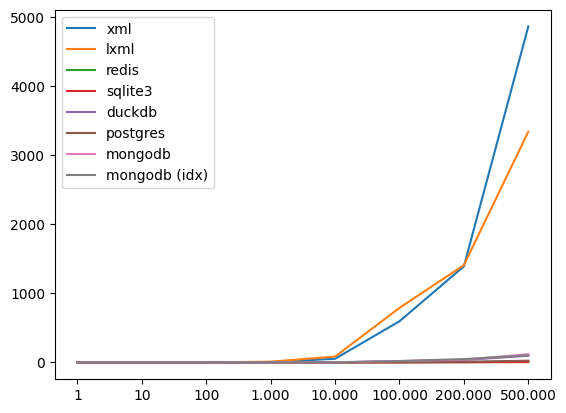

In [71]:
#daz
cols = [c for c in df.columns if c != 'db']

categories=[f"{x:,.0f}".replace(',', '.') for x in cols]

for _, row in df.iterrows():
    plt.plot(categories, row[cols], label=row['db'])
    #plt.plot(row[cols], cols, label=row['db'])

plt.legend()
plt.savefig('../data/plots/performance_all.pdf')
plt.show()

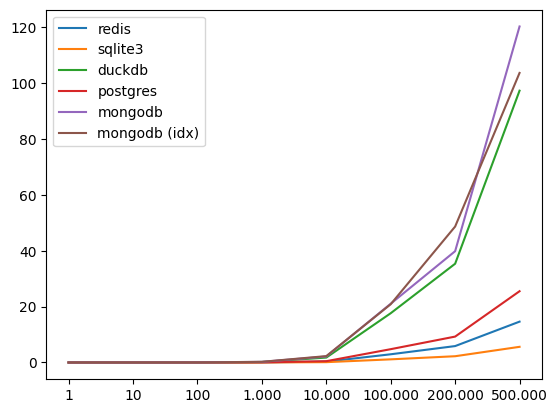

In [72]:
df2=df[(df['db']!='xml') & (df['db']!='lxml')]
cols = [c for c in df2.columns if c != 'db']
categories=[f"{x:,.0f}".replace(',', '.') for x in cols]

for _, row in df2.iterrows():
    plt.plot(categories, row[cols], label=row['db'])

plt.legend()
plt.savefig('../data/plots/performance_no_xml.pdf')
plt.show()

In [73]:
df_init=pd.DataFrame(init_times)
df_init

,db,duration
0,xml,0.006687
1,lxml,0.006687
2,redis,0.035152
3,sqlite3,0.158131
4,duckdb,9.878789
5,postgres,2.671035
6,mongodb,0.077679
7,mongodb (idx),0.091058


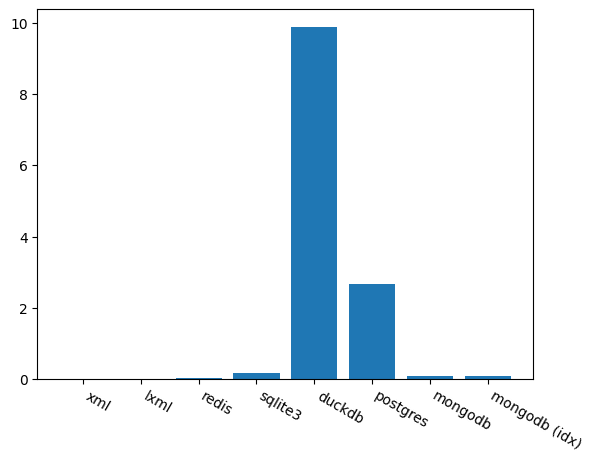

In [74]:
plt.bar(df_init['db'], df_init['duration'], label=row['db'])
plt.xticks(rotation=330,ha='left')
plt.savefig('../data/plots/init_all.pdf')
plt.show()

In [75]:
# save the dataframe for later usage
# only uncomment the next three lines if you REALLY want to override all saved data
df.to_pickle("../data/df.pickle")
df_init.to_pickle("../data/df_init.pickle")
df_backup=df
last_updated=datetime.now()
print(f"Saved last at: {last_updated}")

Saved last at: 2026-05-13 23:58:30.845273


In [76]:
print(f"Done at: {datetime.now()} with {fake_k} fake records.")

Done at: 2026-05-13 23:58:30.881126 with 100000 fake records.
